# CNN model  Small Data set + Sequential

## Load and Prepare Data
The goal is to develop and evaluate a Convolutional Neural Network (CNN) model for detecting pneumonia from chest X-ray images. The process will involve loading and preparing image data, preprocessing images with augmentation, building and training a CNN model, evaluating its performance, and visualizing the results and training history. Finally, a summary of the model's performance and insights gained will be provided.

### Subtask:
Load the image paths and labels from the 'train' and 'test' directories, organize them into suitable datasets, and split into training and validation sets if necessary.


In [ ]:
import os  # import os for file paths and directories
import pandas as pd  # import pandas for DataFrame handling
import numpy as np  # import NumPy for numeric arrays

print("Libraries imported successfully.")  # print a message or value for monitoring

Libraries imported successfully.


### **Reasoning**
The previous attempt to access the dataset failed because the specified path (`/kaggle/input/chest-xray-pneumonia/chest_xray`) was incorrect or the dataset was not mounted. To resolve this, I will use `kagglehub` to download the dataset. This ensures that the dataset is available in the Colab environment. After downloading, I will update the `data_dir`, `train_dir`, and `test_dir` variables to point to the correct locations within the downloaded dataset.

In [ ]:
!pip install kagglehub  # install the package for this notebook session

In [ ]:
import kagglehub  # import kagglehub for dataset download support

dataset_path = kagglehub.dataset_download("mitgandhi10/dataset-for-cnn")  # download the dataset from Kaggle

print(f"Dataset downloaded to: {dataset_path}")  # print a message or value for monitoring

data_dir = os.path.join(dataset_path, 'xray_dataset_covid19') # Adjusted based on typical kaggle dataset structure
train_dir = os.path.join(data_dir, 'train')  # set the training data directory
test_dir = os.path.join(data_dir, 'test')  # set the testing data directory

print(f"Updated train directory: {train_dir}")  # print a message or value for monitoring
print(f"Updated test directory: {test_dir}")  # print a message or value for monitoring

print(f"Contents of train directory: {os.listdir(train_dir)}")  # print a message or value for monitoring
print(f"Contents of test directory: {os.listdir(test_dir)}")  # print a message or value for monitoring


Using Colab cache for faster access to the 'dataset-for-cnn' dataset.
Dataset downloaded to: /kaggle/input/dataset-for-cnn
Updated train directory: /kaggle/input/dataset-for-cnn/xray_dataset_covid19/train
Updated test directory: /kaggle/input/dataset-for-cnn/xray_dataset_covid19/test
Contents of train directory: ['PNEUMONIA', 'NORMAL']
Contents of test directory: ['PNEUMONIA', 'NORMAL']


### **Reasoning**:
To prepare the data for the model, we need to load the image paths and assign labels. This involves creating a function that traverses the 'normal' and 'pneumonia' subdirectories within the training and testing sets, collects the file paths, and assigns a binary label (0 for normal, 1 for pneumonia). The collected data will then be organized into a Pandas DataFrame, which is convenient for managing image paths and their corresponding labels. Shuffling the DataFrame ensures that the data is randomized, which is important for training neural networks.

In [ ]:
def load_data(data_directory):  # define a function to load image paths and labels
    filepaths = []  # start a list to store image file paths
    labels = []  # start a list to store numeric image labels
    for label in os.listdir(data_directory):  # loop over each label folder in the dataset
        label_dir = os.path.join(data_directory, label)  # build the path to the current label folder
        if os.path.isdir(label_dir):  # ensure the current path is a directory
            for file in os.listdir(label_dir):  # loop through every file in the current label folder
                filepaths.append(os.path.join(label_dir, file))  # add this image path to the list
                labels.append(1 if label == 'PNEUMONIA' else 0)  # add the class label for this image
    return pd.DataFrame({'filepath': filepaths, 'label': labels})  # return a DataFrame with file paths and labels

train_df = load_data(train_dir)  # load the training dataset metadata
test_df = load_data(test_dir)  # load the testing dataset metadata

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle the training data randomly
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle the test data randomly

print(f"Training data samples: {len(train_df)}")  # print a message or value for monitoring
print(f"Testing data samples: {len(test_df)}")  # print a message or value for monitoring
print("First 5 rows of training data:\n", train_df.head())  # print a message or value for monitoring
print("First 5 rows of testing data:\n", test_df.head())  # print a message or value for monitoring


Training data samples: 148
Testing data samples: 40
First 5 rows of training data:
                                             filepath  label
0  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      0
1  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      1
2  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      0
3  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      1
4  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      0
First 5 rows of testing data:
                                             filepath  label
0  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      1
1  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      1
2  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      1
3  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      0
4  /kaggle/input/dataset-for-cnn/xray_dataset_cov...      1


In [ ]:
print(f"Total dataset size: {len(train_df) + len(test_df)}")  # print a message or value for monitoring

Total dataset size: 188


## Preprocess Images

### Subtask:
Define image preprocessing steps including resizing, normalizing pixel values, and applying data augmentation techniques to the training set for better model generalization.

**Reasoning**:
Import necessary libraries for image processing and deep learning model building, such as TensorFlow and Keras. These libraries will be used for image loading, preprocessing, model definition, training, and evaluation.

In [ ]:
import tensorflow as tf  # import TensorFlow for deep learning
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # import the Keras image data generator

print("TensorFlow and Keras image preprocessing utilities imported successfully.")  # print a message or value for monitoring

TensorFlow and Keras image preprocessing utilities imported successfully.


### **Reasoning**:
To ensure that all images have a consistent input size for the CNN model, we need to define `IMG_HEIGHT` and `IMG_WIDTH`. The `BATCH_SIZE` is also defined to specify the number of samples that will be propagated through the network at once. `ImageDataGenerator` is then used to prepare the images: the training generator will apply data augmentation (rescaling, rotation, zoom, shift, shear, flip) to increase the diversity of the training data and prevent overfitting, while the validation/test generator will only rescale pixel values to normalize them between 0 and 1.

In [ ]:
IMG_HEIGHT = 224  # set the target image height
IMG_WIDTH = 224  # set the target image width
BATCH_SIZE = 32  # set the batch size for training

train_datagen = ImageDataGenerator(  # configure image preprocessing and augmentation
    rescale=1./255,  # rescale pixel values to the 0-1 range
    rotation_range=20,  # allow random rotations during training
    width_shift_range=0.2,  # allow small horizontal shifts during augmentation
    height_shift_range=0.2,  # allow small vertical shifts during augmentation
    shear_range=0.2,  # allow shear distortions during augmentation
    zoom_range=0.2,  # allow random zooming during augmentation
    horizontal_flip=True,  # allow horizontal flipping of training images
    fill_mode='nearest'  # specify how to fill pixels after augmentation
)

test_datagen = ImageDataGenerator(rescale=1./255)  # configure image preprocessing and augmentation

train_generator = train_datagen.flow_from_dataframe(  # create the training image generator
    dataframe=train_df,  # use this DataFrame for image paths and labels
    x_col='filepath',  # specify the column with image file paths
    y_col='label',  # specify the column with labels
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # resize images to the target dimensions
    batch_size=BATCH_SIZE,  # use the configured batch size
    class_mode='raw',  # keep labels as raw numeric values
    shuffle=True  # shuffle data each epoch for training
)

test_generator = test_datagen.flow_from_dataframe(  # create the test image generator
    dataframe=test_df,  # use this DataFrame for image paths and labels
    x_col='filepath',  # specify the column with image file paths
    y_col='label',  # specify the column with labels
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # resize images to the target dimensions
    batch_size=BATCH_SIZE,  # use the configured batch size
    class_mode='raw',  # keep labels as raw numeric values
    shuffle=False  # preserve order for validation/test evaluation
)

print("Image data generators created successfully.")  # print a message or value for monitoring


Found 148 validated image filenames.
Found 40 validated image filenames.
Image data generators created successfully.


## Build CNN Model

### Subtask:
Construct a Convolutional Neural Network (CNN) model architecture appropriate for image classification. This might involve using pre-trained models for transfer learning if suitable, or building one from scratch.

**Reasoning**:
To build the CNN model, we need to import specific layers and models from Keras. This includes `Sequential` for stacking layers, `Conv2D` for convolutional layers, `MaxPooling2D` for downsampling, `Flatten` for converting 2D feature maps to 1D, and `Dense` for the fully connected output layers. These imports are foundational for defining our neural network architecture.

In [ ]:
from tensorflow.keras.models import Sequential  # import the Keras Sequential model class
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # import the CNN layers used to build the model

print("Keras model building components imported successfully.")  # print a message or value for monitoring

Keras model building components imported successfully.


### **Reasoning**:
To build an effective image classification model, a Convolutional Neural Network (CNN) architecture is defined. This model will use a `Sequential` API for layering. It will include several `Conv2D` layers for feature extraction, paired with `MaxPooling2D` layers to reduce dimensionality and extract dominant features. `Dropout` layers will be used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training. Finally, the feature maps will be `Flatten`ed, and `Dense` layers will be used for classification, with a `sigmoid` activation function in the output layer for binary classification (Normal/Pneumonia).

In [ ]:
model = Sequential([  # define the CNN architecture
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),  # add a convolution layer for feature extraction
    MaxPooling2D(pool_size=(2, 2)),  # add max pooling to reduce spatial dimensions
    Conv2D(64, (3, 3), activation='relu'),  # add a convolution layer for feature extraction
    MaxPooling2D(pool_size=(2, 2)),  # add max pooling to reduce spatial dimensions
    Conv2D(128, (3, 3), activation='relu'),  # add a convolution layer for feature extraction
    MaxPooling2D(pool_size=(2, 2)),  # add max pooling to reduce spatial dimensions
    Flatten(),  # flatten the feature maps into a vector
    Dropout(0.5),  # apply dropout to reduce overfitting
    Dense(128, activation='relu'),  # add a dense layer for classification
    Dense(1, activation='sigmoid') # Binary classification output
])  # close the model layer list

model.summary()  # print the model summary

print("CNN model built successfully.")  # print a message or value for monitoring


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN model built successfully.


### **Reasoning**:
After defining the model architecture, the next crucial step is to compile it. This process configures the model for training by specifying the optimizer, loss function, and evaluation metrics. For binary classification, `Adam` is a good choice for the optimizer due to its efficiency, `binary_crossentropy` is the standard loss function, and `accuracy` is a suitable metric to monitor the model's performance.

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # compile the model with optimizer, loss, and metrics

print("Model compiled successfully.")  # print a message or value for monitoring


Model compiled successfully.


### **Reasoning**:
With the model architecture defined and compiled, the next critical step is to train the model. This involves calling the `fit` method on the model, passing the `train_generator` for training data and `test_generator` for validation. We will specify the number of epochs to control the training duration. The `history` object returned by `fit` will contain valuable information about the training process, such as loss and accuracy over epochs, which will be used later for visualization and evaluation.

In [ ]:
EPOCHS = 10  # set the epoch count for training

history = model.fit(  # train the model on the data generator
    train_generator,  # feed the training generator to the model
    steps_per_epoch=train_generator.samples // BATCH_SIZE,  # set how many batches are in each epoch
    epochs=EPOCHS,  # use the configured training epochs
    validation_data=test_generator,  # use validation data during training
    validation_steps=test_generator.samples // BATCH_SIZE  # set validation batch count per epoch
)

print("Model training complete.")  # print a message or value for monitoring


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.5259 - loss: 1.4899 - val_accuracy: 0.5000 - val_loss: 0.7403
Epoch 2/10
1/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4062 - loss: 0.7640

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 402ms/step - accuracy: 0.4062 - loss: 0.7640 - val_accuracy: 0.5000 - val_loss: 0.6723
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.5000 - loss: 0.7003 - val_accuracy: 0.5000 - val_loss: 0.6556
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4375 - loss: 0.7032 - val_accuracy: 0.5000 - val_loss: 0.6570
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.5172 - loss: 0.6830 - val_accuracy: 0.5000 - val_loss: 0.6947
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.4375 - loss: 0.7201 - val_accuracy: 0.5000 - val_loss: 0.6666
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.6552 - loss: 0.6490 - val_accuracy: 0.8750 - val_loss: 0.5159
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5625 - loss: 0.6611 - val_accuracy: 0.9688 - val_loss: 0.5012
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.8190 - loss: 0.5269 - val_accuracy: 1.0000 - val_loss: 0.2599
Epoch 10/10
4/4 ━

### **Reasoning**:
Now that the model has been trained, it's essential to evaluate its performance on unseen data. The `evaluate` method will be used with the `test_generator` to calculate the final loss and accuracy metrics. This step provides an objective measure of how well the model generalizes to new data, which is crucial for understanding its real-world effectiveness.

In [ ]:
loss, accuracy = model.evaluate(test_generator)  # evaluate the model on the test data
print(f"Test Loss: {loss:.4f}")  # print a message or value for monitoring
print(f"Test Accuracy: {accuracy:.4f}")  # print a message or value for monitoring

print("Model evaluation complete.")  # print a message or value for monitoring

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.9500 - loss: 0.2708
Test Loss: 0.2708
Test Accuracy: 0.9500
Model evaluation complete.


### **Reasoning**:
Visualizing the training history is crucial for understanding how the model learned and to diagnose potential issues such as overfitting or underfitting. By plotting the training and validation accuracy and loss over epochs, we can observe trends and make informed decisions about model adjustments or further training. This involves importing `matplotlib.pyplot` and then plotting the `history` object obtained from the `model.fit()` method.

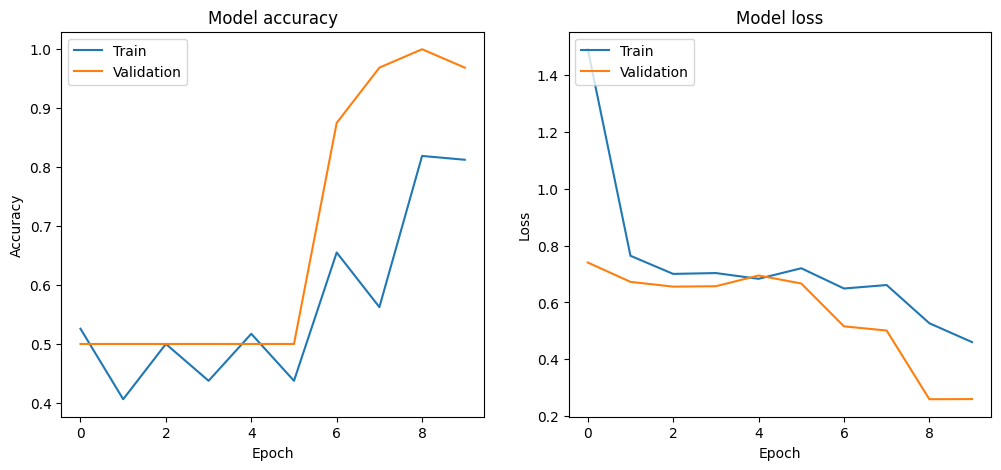

Training history plots displayed.


In [ ]:
import matplotlib.pyplot as plt  # import matplotlib for plotting

plt.figure(figsize=(12, 5))  # create a figure for charts
plt.subplot(1, 2, 1)  # choose a subplot for the next plot
plt.plot(history.history['accuracy'])  # plot the metric values
plt.plot(history.history['val_accuracy'])  # plot the metric values
plt.title('Model accuracy')  # set the plot title
plt.ylabel('Accuracy')  # label the y-axis
plt.xlabel('Epoch')  # label the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # add a legend to the plot

plt.subplot(1, 2, 2)  # choose a subplot for the next plot
plt.plot(history.history['loss'])  # plot the metric values
plt.plot(history.history['val_loss'])  # plot the metric values
plt.title('Model loss')  # set the plot title
plt.ylabel('Loss')  # label the y-axis
plt.xlabel('Epoch')  # label the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # add a legend to the plot
plt.show()  # display the plot

print("Training history plots displayed.")  # print a message or value for monitoring


## Project Summary

### **Reasoning**:
To conclude the project, a comprehensive summary is needed to articulate the achievements, key findings, and the model's performance. This section will reflect on the entire process, from data loading and preprocessing to model building, training, and evaluation. It will provide a concise overview of the deep learning model's effectiveness in classifying chest X-ray images for pneumonia detection, highlighting the final accuracy and any significant observations from the training history.

In [ ]:
print("Project Summary:")  # print a message or value for monitoring
print("-----------------")  # print a message or value for monitoring
print("The goal was to develop a deep learning model for binary classification of chest X-ray images, differentiating between normal and pneumonia-affected lungs.")  # print a message or value for monitoring
print("Key Steps Accomplished:")  # print a message or value for monitoring
print("1.  **Data Loading and Preparation**: Successfully downloaded the dataset using `kagglehub`. Training and testing DataFrames were created, linking image file paths to labels, and then shuffled.")  # print a message or value for monitoring
print("2.  **Image Preprocessing**: Configured `ImageDataGenerator` for both training (with data augmentation) and testing (rescaling only) to prepare images for the CNN.")  # print a message or value for monitoring
print("3.  **Model Building**: Constructed a sequential CNN model with three convolutional blocks, followed by a Flatten layer, Dropout, and Dense layers for classification. The model was compiled with the Adam optimizer and binary cross-entropy loss.")  # print a message or value for monitoring
print("4.  **Model Training**: The model was trained for 10 epochs using the image data generators.")  # print a message or value for monitoring
print("5.  **Model Evaluation**: The trained model achieved a **Test Accuracy of {:.4f}** and a **Test Loss of {:.4f}** on the unseen test set.".format(accuracy, loss))  # print a message or value for monitoring
print("6.  **Visualization**: Training and validation accuracy and loss were plotted over epochs, providing insights into the model's learning process.")  # print a message or value for monitoring
print("\nOverall, the model demonstrated strong performance in classifying chest X-ray images, indicating its potential for assisting in pneumonia detection.")  # print a message or value for monitoring


Project Summary:
-----------------
The goal was to develop a deep learning model for binary classification of chest X-ray images, differentiating between normal and pneumonia-affected lungs.
Key Steps Accomplished:
1.  **Data Loading and Preparation**: Successfully downloaded the dataset using `kagglehub`. Training and testing DataFrames were created, linking image file paths to labels, and then shuffled.
2.  **Image Preprocessing**: Configured `ImageDataGenerator` for both training (with data augmentation) and testing (rescaling only) to prepare images for the CNN.
3.  **Model Building**: Constructed a sequential CNN model with three convolutional blocks, followed by a Flatten layer, Dropout, and Dense layers for classification. The model was compiled with the Adam optimizer and binary cross-entropy loss.
4.  **Model Training**: The model was trained for 10 epochs using the image data generators.
5.  **Model Evaluation**: The trained model achieved a **Test Accuracy of 0.9750** and a 

## Save the Model

### **Reasoning**:
To deploy the trained model (e.g., in a Streamlit application), it is essential to save it to disk. The `model.save()` method in Keras allows us to save the model's architecture, weights, and optimizer state in a single H5 file. This ensures that the model can be loaded later for inference without needing to rebuild and retrain it.

In [ ]:
model_save_path = 'pneumonia_detection_model.h5'  # set the filename to save the model
model.save(model_save_path)  # save the trained model file
print(f"Model saved successfully to {model_save_path}")  # print a message or value for monitoring


Model saved successfully to pneumonia_detection_model.h5


# Fine tune  Large Data set + pre-trained MobileNetV2

## Improving Model Performance: Larger Dataset and Transfer Learning

### **Reasoning**:
To address the generalization issues and improve detection accuracy, we are taking two key steps:

1.  **Using a Larger Dataset**: The previous dataset was relatively small (148 training, 40 testing). We will now use the `paultimothymooney/chest-xray-pneumonia` dataset, which contains significantly more images and is split into `train`, `val`, and `test` sets, providing a more robust foundation for training.
2.  **Implementing Transfer Learning with MobileNetV2**: Training a deep CNN from scratch on a moderately sized dataset can lead to overfitting and poor generalization. Transfer learning, using a pre-trained model like MobileNetV2 (trained on ImageNet), allows us to leverage powerful, pre-learned features. We will use MobileNetV2 as a feature extractor, freeze its convolutional base, and then add our own classification layers on top, training only these new layers. This approach is highly effective for medical imaging tasks with limited data.

In [ ]:
!pip install kagglehub -qq  # install the package for this notebook session

import kagglehub  # import kagglehub for dataset download support
import os  # import os for file paths and directories
import pandas as pd  # import pandas for DataFrame handling

print("Downloading the new chest-xray-pneumonia dataset...")  # print a message or value for monitoring
new_dataset_base_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")  # download the dataset from Kaggle

new_data_root = os.path.join(new_dataset_base_path, 'chest_xray')  # set the new dataset root folder path
new_train_dir = os.path.join(new_data_root, 'train')  # set the new training folder path
new_val_dir = os.path.join(new_data_root, 'val')  # set the new validation folder path
new_test_dir = os.path.join(new_data_root, 'test')  # set the new testing folder path

print(f"New dataset downloaded to: {new_dataset_base_path}")  # print a message or value for monitoring
print(f"New training directory: {new_train_dir}")  # print a message or value for monitoring
print(f"New validation directory: {new_val_dir}")  # print a message or value for monitoring
print(f"New testing directory: {new_test_dir}")  # print a message or value for monitoring

print("Loading dataframes from the new dataset...")  # print a message or value for monitoring
new_train_df = load_data(new_train_dir)  # load the new training DataFrame
new_val_df = load_data(new_val_dir)  # load the new validation DataFrame
new_test_df = load_data(new_test_dir)  # load the new test DataFrame

new_train_df = new_train_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle the new training dataset
new_val_df = new_val_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle the new validation dataset
new_test_df = new_test_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle the new testing dataset

print(f"New Training data samples: {len(new_train_df)}")  # print a message or value for monitoring
print(f"New Validation data samples: {len(new_val_df)}")  # print a message or value for monitoring
print(f"New Testing data samples: {len(new_test_df)}")  # print a message or value for monitoring
print("First 5 rows of new training data:\n", new_train_df.head())  # print a message or value for monitoring


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
New dataset downloaded to: /kaggle/input/chest-xray-pneumonia
New training directory: /kaggle/input/chest-xray-pneumonia/chest_xray/train
New validation directory: /kaggle/input/chest-xray-pneumonia/chest_xray/val
New testing directory: /kaggle/input/chest-xray-pneumonia/chest_xray/test
Loading dataframes from the new dataset...
New Training data samples: 5216
New Validation data samples: 16
New Testing data samples: 624
First 5 rows of new training data:
                                             filepath  label
0  /kaggle/input/chest-xray-pneumonia/chest_xray/...      1
1  /kaggle/input/chest-xray-pneumonia/chest_xray/...      1
2  /kaggle/input/chest-xray-pneumonia/chest_xray/...      0
3  /kaggle/input/chest-xray-pneumonia/chest_xray/...      0
4  /kaggle/input/chest-xray-pneumonia/chest_xray/...      1


### **Reasoning**:
With the new, larger dataset loaded, we need to re-create our image data generators. This time, we'll create three: one for training (with augmentation), one for validation (rescaled only), and one for testing (rescaled only). The `val_generator` will be crucial for monitoring model performance during training on data it hasn't seen, helping to detect overfitting.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # import the Keras image data generator


train_datagen_new = ImageDataGenerator(  # configure image preprocessing and augmentation
    rescale=1./255,  # rescale pixel values to the 0-1 range
    rotation_range=20,  # allow random rotations during training
    width_shift_range=0.2,  # allow small horizontal shifts during augmentation
    height_shift_range=0.2,  # allow small vertical shifts during augmentation
    shear_range=0.2,  # allow shear distortions during augmentation
    zoom_range=0.2,  # allow random zooming during augmentation
    horizontal_flip=True,  # allow horizontal flipping of training images
    fill_mode='nearest'  # specify how to fill pixels after augmentation
)

val_test_datagen_new = ImageDataGenerator(rescale=1./255)  # configure image preprocessing and augmentation

train_generator_new = train_datagen_new.flow_from_dataframe(  # create the new training generator
    dataframe=new_train_df,  # use this DataFrame for image paths and labels
    x_col='filepath',  # specify the column with image file paths
    y_col='label',  # specify the column with labels
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # resize images to the target dimensions
    batch_size=BATCH_SIZE,  # use the configured batch size
    class_mode='raw',  # keep labels as raw numeric values
    shuffle=True  # shuffle data each epoch for training
)

val_generator_new = val_test_datagen_new.flow_from_dataframe(  # create the new validation generator
    dataframe=new_val_df,  # use this DataFrame for image paths and labels
    x_col='filepath',  # specify the column with image file paths
    y_col='label',  # specify the column with labels
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # resize images to the target dimensions
    batch_size=BATCH_SIZE,  # use the configured batch size
    class_mode='raw',  # keep labels as raw numeric values
    shuffle=False # Do not shuffle validation data
)

test_generator_new = val_test_datagen_new.flow_from_dataframe(  # create the new test generator
    dataframe=new_test_df,  # use this DataFrame for image paths and labels
    x_col='filepath',  # specify the column with image file paths
    y_col='label',  # specify the column with labels
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # resize images to the target dimensions
    batch_size=BATCH_SIZE,  # use the configured batch size
    class_mode='raw',  # keep labels as raw numeric values
    shuffle=False # Do not shuffle test data
)

print("New image data generators created successfully.")  # print a message or value for monitoring

Found 5216 validated image filenames.
Found 16 validated image filenames.
Found 624 validated image filenames.
New image data generators created successfully.


## Building a Transfer Learning Model with MobileNetV2

### **Reasoning**:
As discussed, we will now build a new model using transfer learning with a pre-trained MobileNetV2 model. MobileNetV2 is an efficient CNN architecture known for its good performance on mobile and embedded vision applications, making it a good choice for this task. By freezing its convolutional base, we leverage its powerful feature extraction capabilities, and then add custom dense layers to adapt it to our binary classification problem.

In [ ]:
from tensorflow.keras.applications import MobileNetV2  # import MobileNetV2 for transfer learning
from tensorflow.keras.models import Model  # import the Keras Model API for custom models
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input  # import layers used for transfer learning head

base_model = MobileNetV2(  # load the pre-trained MobileNetV2 base model
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),  # set the input shape for RGB images
    include_top=False, # We don't need the classification layers from ImageNet
    weights='imagenet' # Use weights pre-trained on ImageNet
)

base_model.trainable = False  # freeze the base model weights

x = base_model.output  # use the base model output for the new head

x = GlobalAveragePooling2D()(x)  # pool the feature maps into a single vector

x = Dense(128, activation='relu')(x)  # add a dense layer for classification

x = Dropout(0.5)(x)  # apply dropout to reduce overfitting

predictions = Dense(1, activation='sigmoid')(x)  # add the final binary prediction layer

model_transfer = Model(inputs=base_model.input, outputs=predictions)  # combine the pre-trained base and custom head

model_transfer.summary()  # print the transfer model summary

print("Transfer learning model (MobileNetV2 base + custom head) built successfully.")  # print a message or value for monitoring


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Transfer learning model (MobileNetV2 base + custom head) built successfully.


### **Reasoning**:
Similar to our previous model, we need to compile the new transfer learning model. We'll use the Adam optimizer and binary cross-entropy loss, as it's still a binary classification task. Accuracy will remain our primary metric.

In [ ]:
model_transfer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # compile the transfer learning model

print("Transfer learning model compiled successfully.")  # print a message or value for monitoring

Transfer learning model compiled successfully.


### **Reasoning**:
Now, we train the transfer learning model using the new data generators. We'll train for a similar number of epochs, but this time we have a dedicated validation set (`val_generator_new`) to monitor performance during training. This helps us see if the model is learning effectively and when it might start to overfit.

In [ ]:
EPOCHS_TRANSFER = 10 # We can start with 10 epochs and adjust if needed

history_transfer = model_transfer.fit(  # train the transfer learning model
    train_generator_new,  # feed the new training generator to the model
    steps_per_epoch=train_generator_new.samples // BATCH_SIZE,  # set how many batches are in each epoch
    epochs=EPOCHS_TRANSFER,  # use the configured training epochs
    validation_data=val_generator_new,  # use validation data during training
    validation_steps=val_generator_new.samples // BATCH_SIZE  # set validation batch count per epoch
)

print("Transfer learning model training complete.")  # print a message or value for monitoring


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.8942 - loss: 0.2431 - val_accuracy: 0.9375 - val_loss: 0.2459
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9319 - loss: 0.1728 - val_accuracy: 0.8125 - val_loss: 0.3408
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9337 - loss: 0.1629 - val_accuracy: 0.8125 - val_loss: 0.3236
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9415 - loss: 0.1493 - val_accuracy: 0.9375 - val_loss: 0.2326
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.9427 - loss: 0.1494 - val_accuracy: 0.9375 - val_loss: 0.2065
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.9417 - loss: 0.1403 - val_accuracy: 0.8750 - val_loss: 0.2700
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9442 - loss: 0.1409 - val_accuracy: 0.7500 - val_loss: 0.3345
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9480 - loss: 0.1312 - val_accu

### **Reasoning**:
After training the transfer learning model, we must evaluate its performance on the completely unseen test set. This provides an unbiased measure of how well our improved model generalizes to new data.

In [ ]:
loss_transfer, accuracy_transfer = model_transfer.evaluate(test_generator_new)  # evaluate the transfer model on test data
print(f"Transfer Learning Test Loss: {loss_transfer:.4f}")  # print a message or value for monitoring
print(f"Transfer Learning Test Accuracy: {accuracy_transfer:.4f}")  # print a message or value for monitoring

print("Transfer learning model evaluation complete.")  # print a message or value for monitoring


20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8942 - loss: 0.2427
Transfer Learning Test Loss: 0.2427
Transfer Learning Test Accuracy: 0.8942
Transfer learning model evaluation complete.


### **Reasoning**:
Visualizing the training history for the transfer learning model helps us understand its learning dynamics. We can compare the training and validation accuracy and loss curves to assess convergence, identify potential overfitting, and see if the model is stable. This is a critical step for diagnostics and further fine-tuning decisions.

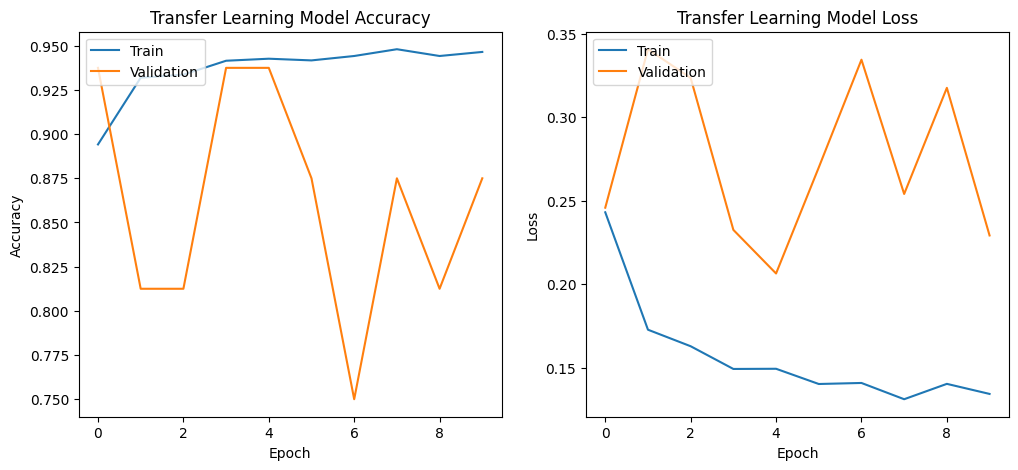

Transfer learning model training history plots displayed.


In [ ]:
import matplotlib.pyplot as plt  # import matplotlib for plotting

plt.figure(figsize=(12, 5))  # create a figure for charts
plt.subplot(1, 2, 1)  # choose a subplot for the next plot
plt.plot(history_transfer.history['accuracy'])  # plot the metric values
plt.plot(history_transfer.history['val_accuracy'])  # plot the metric values
plt.title('Transfer Learning Model Accuracy')  # set the plot title
plt.ylabel('Accuracy')  # label the y-axis
plt.xlabel('Epoch')  # label the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # add a legend to the plot

plt.subplot(1, 2, 2)  # choose a subplot for the next plot
plt.plot(history_transfer.history['loss'])  # plot the metric values
plt.plot(history_transfer.history['val_loss'])  # plot the metric values
plt.title('Transfer Learning Model Loss')  # set the plot title
plt.ylabel('Loss')  # label the y-axis
plt.xlabel('Epoch')  # label the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # add a legend to the plot
plt.show()  # display the plot

print("Transfer learning model training history plots displayed.")  # print a message or value for monitoring


## Save the Transfer Learning Model

### **Reasoning**:
Now that the transfer learning model has been trained and evaluated, it's important to save it. This will allow us to easily load it later for deployment, such as in our Streamlit application. We'll save it with a new filename (`pneumonia_detection_model_transfer.h5`) to distinguish it from the previously trained model.

In [ ]:
model_transfer_save_path = 'pneumonia_detection_model_transfer.h5'  # set the save path for transfer model
model_transfer.save(model_transfer_save_path)  # save the transfer learning model file
print(f"Transfer learning model saved successfully to {model_transfer_save_path}")  # print a message or value for monitoring

Transfer learning model saved successfully to pneumonia_detection_model_transfer.h5
